In [193]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression

import tensorflow as tf

In [194]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object' and col != 'label':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

def train_isolation_forest(X, y, X_test, y_test, n_estimators=50, max_samples='auto', contamination=1e-5, max_features=0.8, C=1.0):    
    # Train the Isolation Forest
    isolation_forest = IsolationForest(n_estimators=n_estimators, max_samples=max_samples, contamination=contamination, max_features=max_features)
    isolation_forest.fit(X)

    # Predict the anomalies using the trained Isolation Forest
    anomaly_scores = isolation_forest.decision_function(X)

    # Train the logistic regression model on the scaled anomaly scores
    log_reg = LogisticRegression(C=C)
    log_reg.fit(anomaly_scores.reshape(-1, 1), y)

    # Evaluate the model on the train set
    y_pred = log_reg.predict(anomaly_scores.reshape(-1, 1))

    f1 = f1_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    accuracy = accuracy_score(y, y_pred)
    
    print(f'\nFor train set: \nF1: {f1}, Precision: {precision}, Recall: {recall}\n, Accuracy: {accuracy}\n')
    
    # Evaluate the model on the test set
    anomaly_scores_test = isolation_forest.decision_function(X_test)
    y_pred_test = log_reg.predict(anomaly_scores_test.reshape(-1, 1))

    f1_test = f1_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test)
    recall_test = recall_score(y_test, y_pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    print(f'\nFor test set: \nF1: {f1_test}, Precision: {precision_test}, Recall: {recall_test}, Accuracy: {accuracy_test}\n')

    cm = confusion_matrix(y_test, y_pred_test)
    plt.title("Confusion Matrix")
    ax = sns.heatmap(cm, annot=True, fmt='0.0f')
    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return f1_test

def multiple_trainining_sessions(df, n_sessions=10):
    sum = 0
    for i in range(n_sessions):
        print(f'\nTraining session {i+1}\n')
        normal = df.query('label == 0').sample(500000)
        attack = df.query('label == 1').sample(10000)

        df_reduced = pd.concat([normal, attack]).sample(frac=1)
        labels = df_reduced['label']
        features = df_reduced.drop('label', axis=1)
        # Conduct a train-test split    
        x_train, x_test, y_train, y_test = train_test_split(features.values, labels.values, test_size = 0.3, random_state = 42)
    
        f1 = train_isolation_forest(x_train, y_train, x_test, y_test)
        sum = sum + f1
    print(f'\nAverage F1 score no scaling: {sum/n_sessions}\n')


In [195]:
columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
        "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
        "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

df_init = pd.read_csv("datasets/kddcup1999/kddcup.data.corrected", sep=",", names=columns, index_col=None)

# Preprocessing

In [196]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['logged_in', 'count', 'dst_host_count', 'protocol_type', 'srv_count', 'dst_host_same_src_port_rate', 'srv_diff_host_rate', 'dst_bytes', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'flag', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'label']

df_feature_selected = df_init[df_init.columns.intersection(keep_cols)]

In [197]:
df_feature_selected_encoded = encode_objects(df_feature_selected)

C:\Users\David\AppData\Local\Temp\ipykernel_2296\66807436.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
C:\Users\David\AppData\Local\Temp\ipykernel_2296\66807436.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])


In [198]:
df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)

C:\Users\David\AppData\Local\Temp\ipykernel_2296\1445368458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)


In [199]:
df_feature_selected_encoded = df_feature_selected_encoded.drop(df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 2e8].index)
df_feature_selected_encoded.shape

(4898428, 16)

In [200]:
normal = df_feature_selected_encoded.query('label == 0').sample(500000)
attack = df_feature_selected_encoded.query('label == 1').sample(10000)

df_reduced = pd.concat([normal, attack]).sample(frac=1)
# df_reduced = df_feature_selected_encoded

In [201]:
labels = df_reduced['label']
features = df_reduced.drop('label', axis=1)
# Conduct a train-test split    
x_train, x_test, y_train, y_test = train_test_split(features.values, labels.values, test_size = 0.3, random_state = 42)

print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(357000, 15)
y_train:(357000,)

x_test:(153000, 15)
y_test:(153000,)


# Hyperparameter tuning

In [202]:
# iso_forest_param_grid = {
#     'n_estimators': [10, 50, 100, 150, 200],
#     'max_samples': ['auto'],
#     'max_features': [0.1, 0.2, 0.5, 0.8, 1.0],
#     'contamination': [1e-6, 1e-5, 1e-4, 1e-2, 1e-1, 0.1, 0.2],
# }

# log_reg_param_grid = {
#     'C': [1e-3, 1e-2, 1e-1, 1, 10, 100]
# }


In [203]:
# from sklearn.model_selection import ParameterGrid, cross_val_score


# best_score = -np.inf
# best_params = None

# for iso_forest_params in ParameterGrid(iso_forest_param_grid):
#     iso_forest = IsolationForest(**iso_forest_params)
#     iso_forest.fit(x_train)
#     X_train_scores = iso_forest.decision_function(x_train)
    
#     for log_reg_params in ParameterGrid(log_reg_param_grid):
#         log_reg = LogisticRegression(**log_reg_params)
#         score = cross_val_score(log_reg, X_train_scores.reshape(-1, 1), y_train, cv=5, scoring='f1').mean()
        
#         if score > best_score:
#             best_score = score
#             best_params = (iso_forest_params, log_reg_params)

# print(f"Best score: {best_score} with params: {best_params}")

# Evaluating


For train set: 
F1: 0.9771496871264853, Precision: 0.961666205369499, Recall: 0.9931399171073317
, Accuracy: 0.9990896358543417


For test set: 
F1: 0.9756017684624202, Precision: 0.959729381443299, Recall: 0.9920079920079921, Accuracy: 0.9990261437908496



0.9756017684624202

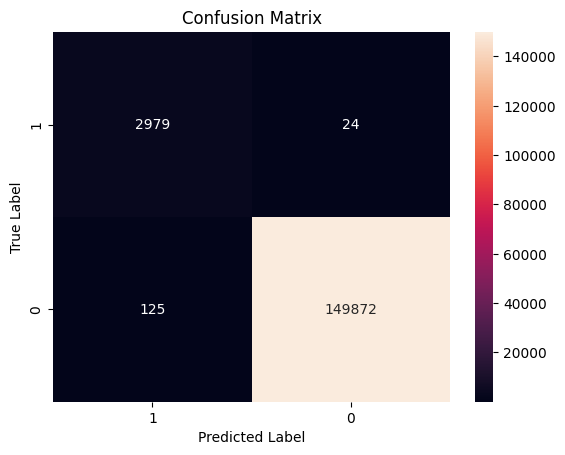

In [204]:
n_estimators = 100
max_samples = 'auto'
contamination = 1e-5
max_features = 0.8
lr_c = 1


train_isolation_forest(x_train, y_train, x_test, y_test, n_estimators=n_estimators, max_samples=max_samples, contamination=contamination, max_features=max_features, C=lr_c)